<a href="https://colab.research.google.com/github/owlmt/QuantumSecurity/blob/main/Shor_Factoring_N143.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compiled Shor's Algorithm for $N = 143$ on Aer
### Generalizing Skosana & Tame, *Sci. Rep.* **11**, 16599 (2021), from $N=21$ to $N=143 = 11\times13$

This notebook factors **143** with the same *compiled, orbit-encoded* strategy the paper used
for 21, running on the **Aer statevector simulator**.

**The idea (same as the paper).** Instead of a full general modular-exponentiation circuit, we
exploit the structure of a chosen base $a$. The powers $\{a^0,a^1,\dots,a^{r-1}\bmod N\}$ form a
single cycle (the *orbit*) of length $r$ = the multiplicative order of $a$. We encode those $r$
residues into $\lceil\log_2 r\rceil$ work qubits, so that "multiply by $a$" becomes a simple
$r$-cycle permutation. Quantum phase estimation on that permutation reads off $s/r$, and
continued fractions recover $r$. For $N=21,a=4$ the orbit was $\{1,4,16\}$ ($r=3$, 2 work qubits);
here for $N=143$ we pick a base with order $r=6$ (3 work qubits).

**Honest framing.**
- This *compiled* circuit (~11 qubits) is genuine order-finding via QPE, but it is **not** a
  general-purpose Shor circuit. A full, uncompiled Shor for 143 needs an 8-qubit work register
  plus reversible modular-arithmetic ancillas and ~16 counting qubits — roughly **24–30+ qubits**,
  near the edge of statevector simulation.
- We use the **ideal noiseless** simulator, so peaks are clean. The paper's hardware contribution
  (relative-phase **Margolus** Toffolis to halve CX count) applied to its specific 21-qubit-level
  circuit; here the permutations are kept abstract, but a hardware build would decompose them into
  Toffoli/Margolus gates the same way.
- Factoring 143 demonstrates the *mechanism*; it gives no practical capability against
  cryptographic-size integers.

In [1]:
# Colab setup
!pip install -q qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00


## 1. Pick a base and find its orbit (classical number theory)

Shor needs a base $a$ coprime to $N$ whose order $r$ is **even** and with
$a^{r/2}\not\equiv\pm1 \pmod N$ (otherwise $\gcd(a^{r/2}\pm1,N)$ gives only trivial factors and
you simply try another base). We use $a=23$: its order is $r=6$ and $a^3=12$, a *non-trivial*
square root of $1$ modulo $143$ — exactly the lucky case Shor exploits.

In [2]:
from math import gcd
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

N, a = 143, 23

def multiplicative_order(a, N):
    assert gcd(a, N) == 1
    r, x = 1, a % N
    while x != 1:
        x = (x * a) % N; r += 1
    return r

r = multiplicative_order(a, N)
orbit = [pow(a, i, N) for i in range(r)]   # a^0, a^1, ..., a^(r-1)
half  = pow(a, r // 2, N)
print(f"N = {N} = 11 x 13")
print(f"base a = {a}")
print(f"order r = {r}   (even: {r % 2 == 0})")
print(f"orbit (a^i mod N) = {orbit}")
print(f"a^(r/2) = a^{r//2} = {half}   (must be != 1 and != {N-1}: "
      f"{half not in (1, N-1)})")
print(f"\nEncoding: residue orbit[i]  <->  work-register state |i> (3 qubits):")
for i, val in enumerate(orbit):
    print(f"   |{i:03b}>  <->  a^{i} = {val}")

N = 143 = 11 x 13
base a = 23
order r = 6   (even: True)
orbit (a^i mod N) = [1, 23, 100, 12, 133, 56]
a^(r/2) = a^3 = 12   (must be != 1 and != 142: True)

Encoding: residue orbit[i]  <->  work-register state |i> (3 qubits):
   |000>  <->  a^0 = 1
   |001>  <->  a^1 = 23
   |010>  <->  a^2 = 100
   |011>  <->  a^3 = 12
   |100>  <->  a^4 = 133
   |101>  <->  a^5 = 56


## 2. The encoded "multiply-by-$a$" unitary

In the encoded space, multiplying by $a$ sends $a^i \mapsto a^{i+1}$, i.e. the work-register
state $|i\rangle \mapsto |i+1 \bmod r\rangle$. That is an **$r$-cycle permutation** on the first
$r$ of the $2^3=8$ basis states (the 2 unused states are left fixed). Its eigenvalues are
$e^{2\pi i s/r}$ for $s=0,\dots,r-1$ — the phases QPE will estimate.

In [3]:
dim = 8  # 3 work qubits
def cycle_unitary(cycle_len, dim=8):
    M = np.eye(dim)
    for i in range(cycle_len):
        M[:, i] = 0
        M[(i + 1) % cycle_len, i] = 1
    return M

U = cycle_unitary(r)
assert np.allclose(U @ U.T, np.eye(dim)), "U must be a permutation (unitary)"
print(f"multiply-by-{a} as a {r}-cycle on |0>..|{r-1}> (real part, integer entries):")
print(U.astype(int))
# sanity: applying U^r returns to start
assert np.allclose(np.linalg.matrix_power(U, r), np.eye(dim))
print(f"\nU^{r} = I  (order {r}) confirmed")

multiply-by-23 as a 6-cycle on |0>..|5> (real part, integer entries):
[[0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1]]

U^6 = I  (order 6) confirmed


## 3. Build the order-finding circuit (QPE)

We use **8 control qubits** for sharp resolution of the peaks at $s/6$, plus the 3 work qubits.
The work register starts in $|0\rangle$ (= encoded residue $a^0=1$). We Hadamard the control
register, apply controlled-$U^{2^j}$, then the inverse QFT, then measure.

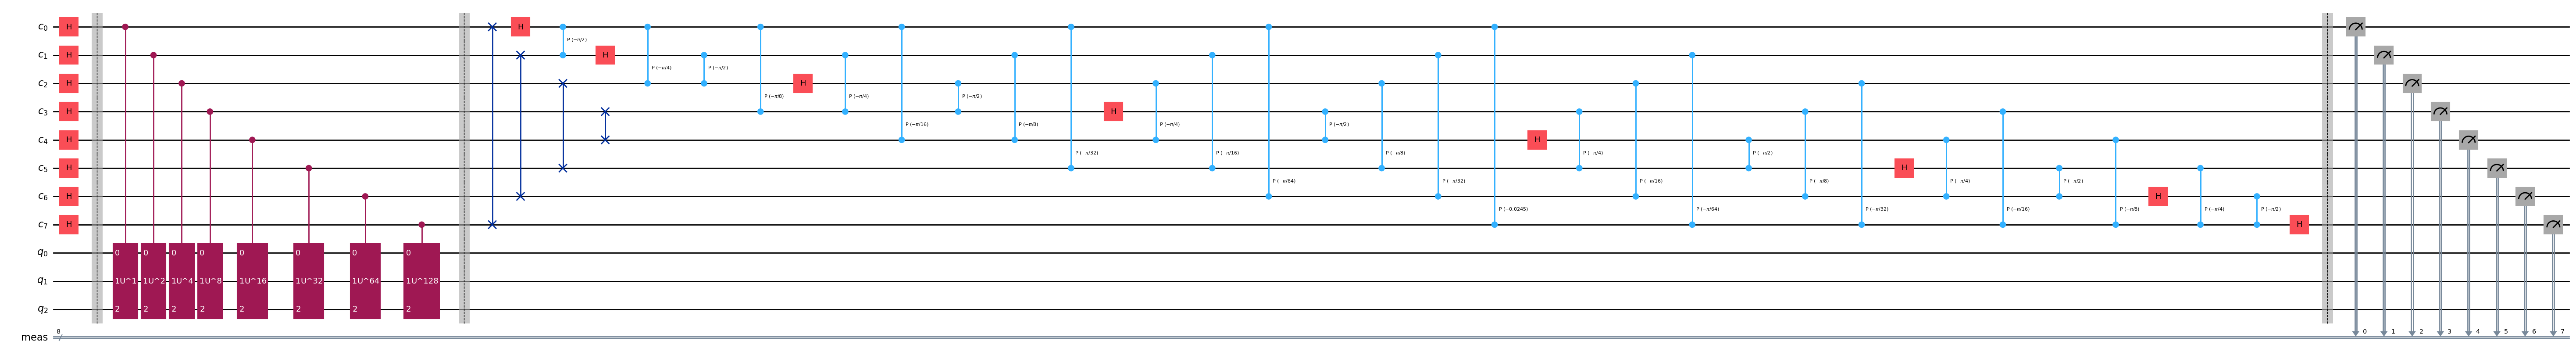

In [4]:
t = 8  # control-register qubits (resolution); total circuit = 8 + 3 = 11 qubits
work = QuantumRegister(3, 'q')
ctrl = QuantumRegister(t, 'c')
cl   = ClassicalRegister(t, 'meas')
qc = QuantumCircuit(ctrl, work, cl)

qc.h(ctrl)                       # work already in |0> = a^0 = 1
qc.barrier()
for j in range(t):               # controlled U^(2^j)
    Up = np.linalg.matrix_power(U, 2 ** j)
    qc.append(UnitaryGate(Up, label=f"U^{2**j}").control(1),
              [ctrl[j], work[0], work[1], work[2]])
qc.barrier()

def inverse_qft(circ, qubits):   # explicit inverse QFT
    n = len(qubits)
    for i in range(n // 2):
        circ.swap(qubits[i], qubits[n - 1 - i])
    for j in range(n):
        for m in range(j):
            circ.cp(-np.pi / 2 ** (j - m), qubits[m], qubits[j])
        circ.h(qubits[j])

inverse_qft(qc, list(ctrl))
qc.barrier()
qc.measure(ctrl, cl)
qc.draw('mpl', fold=-1)

## 4. Run on the Aer simulator

Peaks appear at $\varphi_s \approx 2^{t}\,s/r = 256\,s/6 \in \{0, 43, 85, 128, 171, 213\}$.

Transpiled CX: 153   depth: 321


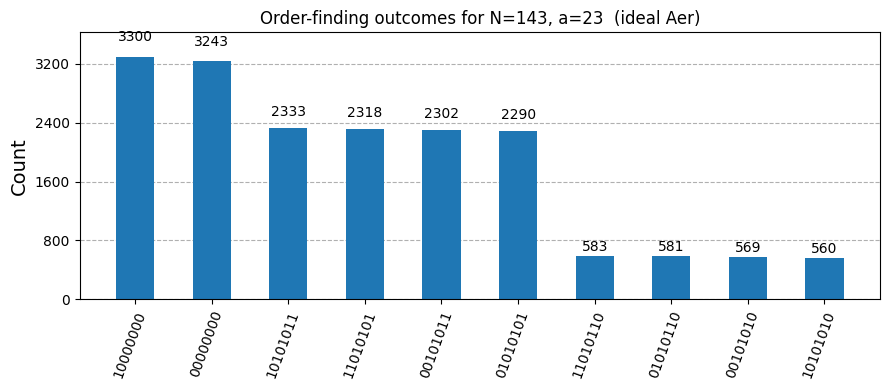

In [5]:
sim = AerSimulator()
tqc = transpile(qc, sim)
counts = sim.run(tqc, shots=20000).result().get_counts()
print(f"Transpiled CX: {tqc.count_ops().get('cx',0)}   depth: {tqc.depth()}")
plot_histogram(counts, sort='value_desc', number_to_keep=10, figsize=(9,4),
               title=f'Order-finding outcomes for N=143, a=23  (ideal Aer)')

In [6]:
tot = sum(counts.values())
print(f"Expected peaks at 256*s/6 for s=0..5:  {[round(256*s/6) for s in range(6)]}\n")
print("Top outcomes (bitstring -> integer phi_s -> probability):")
for bs, c in sorted(counts.items(), key=lambda kv: -kv[1])[:8]:
    print(f"  {bs} -> {int(bs,2):>3}    p = {c/tot:.3f}")

Expected peaks at 256*s/6 for s=0..5:  [0, 43, 85, 128, 171, 213]

Top outcomes (bitstring -> integer phi_s -> probability):
  10000000 -> 128    p = 0.165
  00000000 ->   0    p = 0.162
  10101011 -> 171    p = 0.117
  11010101 -> 213    p = 0.116
  00101011 ->  43    p = 0.115
  01010101 ->  85    p = 0.115
  11010110 -> 214    p = 0.029
  01010110 ->  86    p = 0.029


## 5. Continued fractions $\to r \to$ factors

For each peak $\varphi_s$ we expand $\varphi_s/2^t$ as a continued fraction; a convergent
denominator $q$ with $a^{q}\equiv1\pmod N$ is the order $r$. Peaks with $s$ coprime to $r$
(here $s=1,5 \Rightarrow \varphi=43,213$) yield $r=6$ directly; others give a divisor, so in
practice you test several peaks (or take an lcm).

With $r=6$: $a^{r/2}=23^3=12$, and $\gcd(12-1,143)=11$, $\gcd(12+1,143)=13$.

In [7]:
def convergents(num, den):
    a_, b_ = num, den; cf = []
    while b_:
        cf.append(a_ // b_); a_, b_ = b_, a_ % b_
    h0, h1, k0, k1 = 0, 1, 1, 0; convs = []
    for q in cf:
        h0, h1 = h1, q*h1 + h0
        k0, k1 = k1, q*k1 + k0
        convs.append((h1, k1))
    return convs

recovered = set()
for bs, c in sorted(counts.items(), key=lambda kv: -kv[1]):
    if c / tot < 0.04: continue
    phi = int(bs, 2)
    if phi == 0:
        print(f"  {bs}: phi=0  -> non-informative outcome (expected)")
        continue
    found = None
    for h, q in convergents(phi, 2 ** t):
        if 0 < q < N and pow(a, q, N) == 1:
            found = q; break
    print(f"  {bs}: phi={phi}/{2**t}  ->  r = {found}")
    if found: recovered.add(found)

r_found = 6 if 6 in recovered else max(recovered)
half = pow(a, r_found // 2, N)
f1, f2 = gcd(half - 1, N), gcd(half + 1, N)
print(f"\nUsing r = {r_found}:  a^(r/2) = {a}^{r_found//2} mod {N} = {half}")
print(f"gcd({half}-1, {N}) = {f1},   gcd({half}+1, {N}) = {f2}")
print(f"==>  {N} = {f1} x {f2}")
assert f1 * f2 == N and {f1, f2} == {11, 13}
print("Factoring of 143 succeeded.")

  10000000: phi=128/256  ->  r = None
  00000000: phi=0  -> non-informative outcome (expected)
  10101011: phi=171/256  ->  r = None
  11010101: phi=213/256  ->  r = 6
  00101011: phi=43/256  ->  r = 6
  01010101: phi=85/256  ->  r = None

Using r = 6:  a^(r/2) = 23^3 mod 143 = 12
gcd(12-1, 143) = 11,   gcd(12+1, 143) = 13
==>  143 = 11 x 13
Factoring of 143 succeeded.


## Summary

| | $N=21$ (original) | $N=143$ (this notebook) |
|---|---|---|
| Factors | $3\times7$ | $11\times13$ |
| Base $a$ | $4$ | $23$ |
| Order $r$ | $3$ | $6$ |
| Work qubits ($\lceil\log_2 r\rceil$) | $2$ | $3$ |
| Control qubits | $3$ | $8$ |
| $a^{r/2}\bmod N$ | $8$ (perfect-square branch) | $12$ (non-trivial $\sqrt1$) |

The compiled orbit-encoding scales the same way to any semiprime *as long as the chosen base has
a small order* — which is the catch. For cryptographic $N$, orders are astronomically large and no
small-orbit compilation exists, so genuine attacks require the full modular-exponentiation circuit
on thousands of fault-tolerant qubits. To explore the hardware regime here, attach an Aer
`NoiseModel`; to make it less "compiled," replace the cycle permutation with a residue-encoded
8-qubit work register holding $a^x \bmod 143$ directly (≈16 qubits, still simulable).